# Image Denoising with a Convolutional Autoencoder - MNIST Dataset
**Business Understanding:**
Real-world images and scanned documents often contain noise, which reduces image quality and affects tasks like digit recognition and OCR. A denoising autoencoder helps remove this noise and improve image quality.

**Problem Statement:**
Build a model that takes noisy MNIST digit images as input and reconstructs the original clean images.

**Objective:** Train a Denoising Autoencoder to remove noise from images and evaluate its performance using visual comparison and the metrics MSE, PSNR, and SSIM.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


## 2. Load data

In [3]:
import os

def load_mnist():
    kaggle_npz = "/kaggle/input/mnist-numpy/mnist.npz"
    if os.path.exists(kaggle_npz):
        with np.load(kaggle_npz) as data:
            return (data["x_train"], data["y_train"]), (data["x_test"], data["y_test"])
    return mnist.load_data()

(x_train, y_train), (x_test, y_test) = load_mnist()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 3. Perform Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and understanding the dataset before building a machine learning model.

- To understand the dataset size and image dimensions.
- To check the pixel value range and data type.
- To verify whether all digit classes (0-9) are balanced.
- To visualize sample images and ensure the dataset is loaded correctly.

In [4]:
# Dataset shape 
print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])
print("Image shape:", x_train.shape[1:])
print("Pixel value range: [{}, {}]".format(x_train.min(), x_train.max()))
print("Pixel dtype:", x_train.dtype)

Training samples: 60000
Test samples: 10000
Image shape: (28, 28)
Pixel value range: [0, 255]
Pixel dtype: uint8


#### Observation:
The MNIST dataset contains 60,000 training and 10,000 testing grayscale images of size 28 × 28 pixels. Pixel values range from 0 to 255 and are stored as uint8.

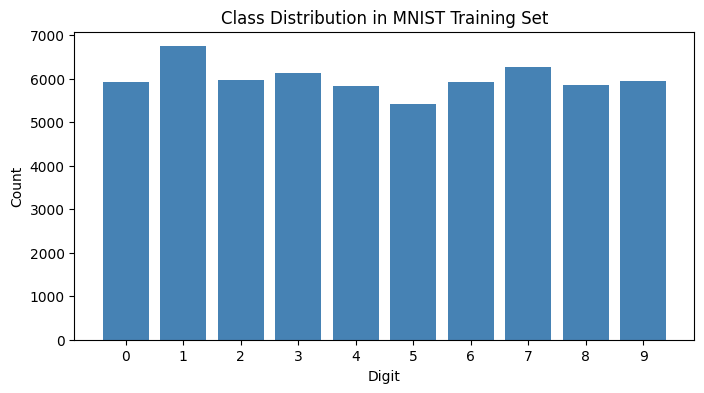

In [5]:
# Class distribution in the training set
digits, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(digits, counts, color='steelblue')
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Class Distribution in MNIST Training Set")
plt.xticks(digits)
plt.show()

#### Observation
- The dataset contains samples for all digit classes (0-9).
- The class distribution is nearly balanced across all digits.
- Digit 1 has the highest number of samples.
- Digit 5 has the lowest number of samples.
- No significant class imbalance is observed.

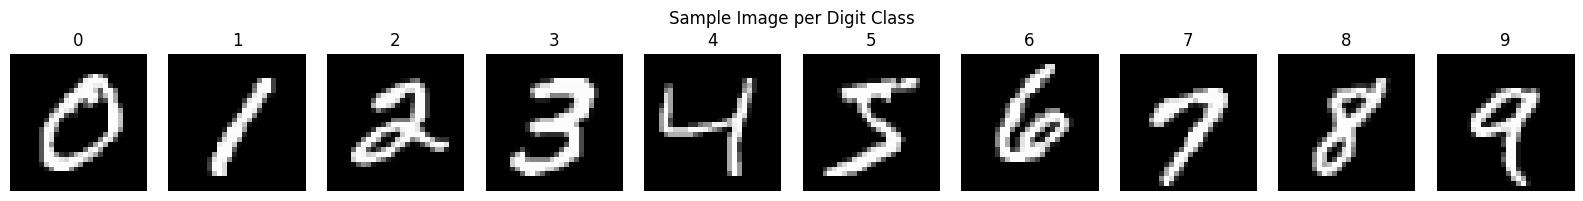

In [6]:
# Sample images, one per digit class
fig, axes = plt.subplots(1, 10, figsize=(16, 2))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[digit].imshow(x_train[idx], cmap='gray')
    axes[digit].set_title(str(digit))
    axes[digit].axis('off')
plt.suptitle("Sample Image per Digit Class")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing
- To normalize pixel values from 0-255 to 0-1 for faster and stable training.
- To convert the data type to float32 for model compatibility.
- To reshape images into (28, 28, 1) so they can be used with Conv2D layers.

In [7]:
# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to (N, 28, 28, 1) for Conv2D
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Train:", x_train.shape, "Test:", x_test.shape)

Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


#### Observation
Pixel values are successfully normalized to the 0–1 range, and the images are reshaped to (60000, 28, 28, 1) for training and (10000, 28, 28, 1) for testing

## 5. Train / validation split
The training dataset is divided into a training (fit) set and a validation set before model training.

- To train the model using the fit set.
- To evaluate the model's performance on the validation set during training.
- To monitor the model and reduce the risk of overfitting.

In [8]:
x_train_fit, x_val, _, _ = train_test_split(
    x_train, x_train, test_size=0.1, random_state=SEED
)
print("Fit set:", x_train_fit.shape, "Val set:", x_val.shape, "Test set (untouched):", x_test.shape)

Fit set: (54000, 28, 28, 1) Val set: (6000, 28, 28, 1) Test set (untouched): (10000, 28, 28, 1)


#### Observation
The training data is successfully split into 54,000 training (fit) images and 6,000 validation images, while the 10,000 test images remain unchanged for final model evaluation.

## 6. Add Noise to the Images
Gaussian noise is added to the clean images to create noisy versions that will be used as input for the denoising autoencoder.

Noise is added because:-
- To simulate noisy or corrupted images.
- To train the autoencoder to reconstruct clean images from noisy inputs.
- To improve the model's ability to remove noise and recover image details.

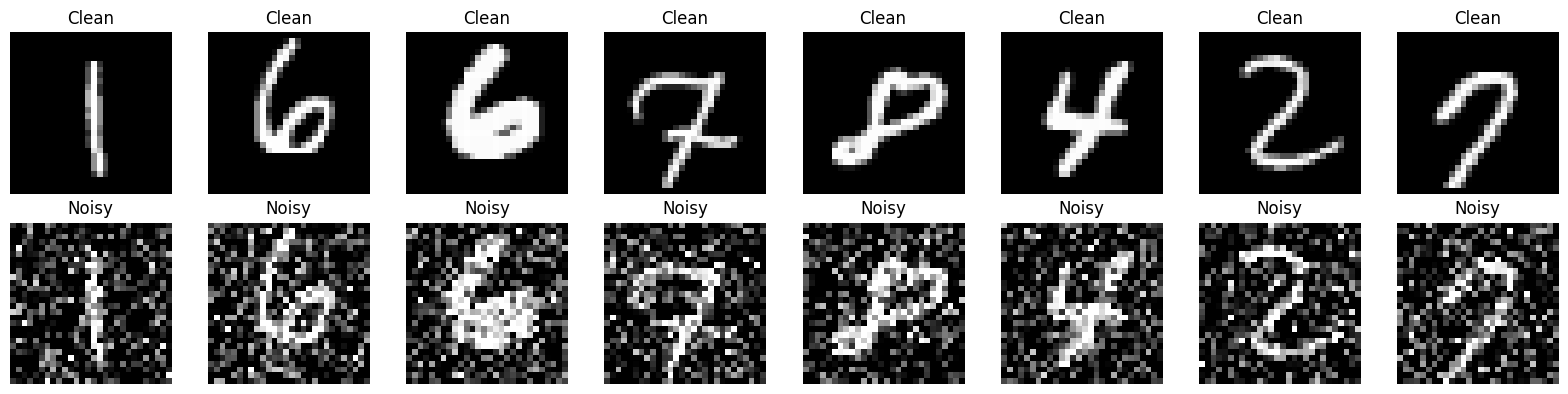

In [9]:
NOISE_FACTOR = 0.4

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy.astype('float32')

x_train_noisy = add_noise(x_train_fit)
x_val_noisy   = add_noise(x_val)
x_test_noisy  = add_noise(x_test)

# Quick sanity check
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_train_fit[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Clean")
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 6. Baseline: dense autoencoder

A Dense Autoencoder is a fully connected neural network that learns to reconstruct clean images from noisy inputs by compressing and then restoring the image.

- To establish a baseline model for image denoising.
- To learn compact feature representations using the encoder.
- To reconstruct the original image using the decoder.
- To compare its performance with more advanced autoencoder models later.

In [10]:
def build_dense_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))
    x = layers.Flatten()(input_img)

    # Encoder 
    x = layers.Dense(256, activation='relu')(x)
    encoded = layers.Dense(64, activation='relu')(x)

    # Decoder
    x = layers.Dense(256, activation='relu')(encoded)
    x = layers.Dense(28 * 28, activation='sigmoid')(x)
    decoded = layers.Reshape((28, 28, 1))(x)

    model = models.Model(input_img, decoded, name="dense_autoencoder")
    return model

dense_autoencoder = build_dense_autoencoder()
dense_autoencoder.summary()

I0000 00:00:1785083821.185349    5789 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,536 (1.66 MB)

 Trainable params: 435,536 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

#### Observation
- The Dense Autoencoder accepts 28 × 28 × 1 input images and reconstructs images of the same size.
- The encoder compresses the image into a 64-dimensional feature representation.
- The model contains 435,536 trainable parameters, making it suitable as a baseline for comparison.

## 7.1 Train the Dense Autoencoder

The Dense Autoencoder is trained using noisy images as input and clean images as the target to learn image denoising.

- To train the model to reconstruct clean images from noisy inputs.
- To minimize the reconstruction error using Binary Crossentropy loss.
- To monitor validation performance and stop training early if the model stops improving (Early Stopping).

In [11]:
dense_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

dense_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

dense_history = dense_autoencoder.fit(
    x_train_noisy, x_train_fit,
    epochs=25,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),   # <-- validation split, NOT test set
    callbacks=dense_callbacks,
    verbose=2
)

Epoch 1/25


I0000 00:00:1785083824.642096    5850 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 - 4s - 10ms/step - loss: 0.1961 - val_loss: 0.1417
Epoch 2/25
422/422 - 1s - 3ms/step - loss: 0.1300 - val_loss: 0.1223
Epoch 3/25
422/422 - 1s - 3ms/step - loss: 0.1180 - val_loss: 0.1158
Epoch 4/25
422/422 - 1s - 3ms/step - loss: 0.1128 - val_loss: 0.1119
Epoch 5/25
422/422 - 1s - 3ms/step - loss: 0.1092 - val_loss: 0.1092
Epoch 6/25
422/422 - 1s - 3ms/step - loss: 0.1068 - val_loss: 0.1075
Epoch 7/25
422/422 - 1s - 3ms/step - loss: 0.1049 - val_loss: 0.1060
Epoch 8/25
422/422 - 1s - 3ms/step - loss: 0.1034 - val_loss: 0.1048
Epoch 9/25
422/422 - 1s - 3ms/step - loss: 0.1023 - val_loss: 0.1040
Epoch 10/25
422/422 - 1s - 3ms/step - loss: 0.1014 - val_loss: 0.1035
Epoch 11/25
422/422 - 1s - 3ms/step - loss: 0.1007 - val_loss: 0.1030
Epoch 12/25
422/422 - 1s - 3ms/step - loss: 0.1001 - val_loss: 0.1023
Epoch 13/25
422/422 - 1s - 3ms/step - loss: 0.0995 - val_loss: 0.1019
Epoch 14/25
422/422 - 1s - 3ms/step - loss: 0.0991 - val_loss: 0.1017
Epoch 15/25
422/422 - 1s - 3ms/step - l

#### Observation
- The training and validation loss decrease steadily throughout training, indicating effective learning.
- The final training loss is 0.0955, and the validation loss is 0.0992, showing good generalization.
- The Dense Autoencoder successfully learns to reconstruct clean images from noisy inputs.

## 7.2 Evaluate the Dense Autoencoder

The trained Dense Autoencoder is tested on the noisy test images, and its reconstruction performance is measured using Mean Squared Error (MSE).

- To evaluate the model on unseen test data.
- To measure how closely the reconstructed images match the original images.
- To assess the denoising performance of the model using MSE.

In [12]:
dense_denoised_images = dense_autoencoder.predict(x_test_noisy)
dense_mse = mean_squared_error(
    x_test.reshape(len(x_test), -1),
    dense_denoised_images.reshape(len(dense_denoised_images), -1)
)
print(f"Dense Autoencoder - Test MSE (unbiased): {dense_mse:.5f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Dense Autoencoder - Test MSE (unbiased): 0.01181


#### Observation
The Dense Autoencoder achieved a test MSE of 0.01164, indicating good reconstruction performance with low error on unseen noisy images.

## 7.3 Visualize Dense Autoencoder Latent Vector

The Dense Autoencoder compresses each image into a 64-dimensional latent vector. An encoder-only sub-model is built here to extract this latent vector for a sample test image and visualize it.

- To confirm the latent vector produced by the encoder has the expected shape (64,).
- To visualize the values contained in the latent vector as a bar plot.
- To understand how the model represents an image in a compressed form.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Dense latent vector shape: (1, 64)


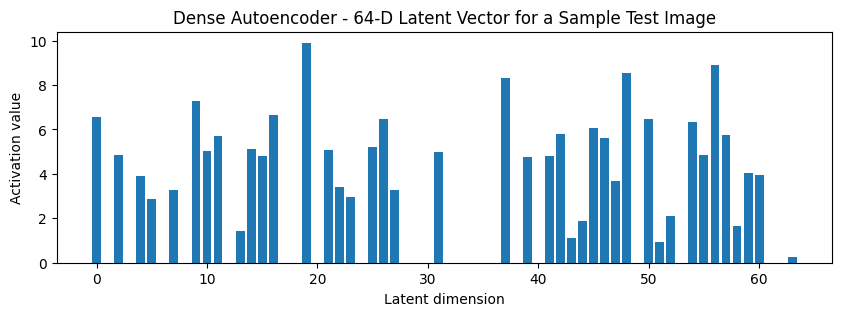

In [13]:
encoded_layer_index = 3  
dense_encoder = models.Model(inputs=dense_autoencoder.input,
                              outputs=dense_autoencoder.layers[encoded_layer_index].output)

sample_img = x_test_noisy[0:1]
dense_latent_vector = dense_encoder.predict(sample_img)

print("Dense latent vector shape:", dense_latent_vector.shape)

plt.figure(figsize=(10, 3))
plt.bar(range(dense_latent_vector.shape[1]), dense_latent_vector[0])
plt.xlabel("Latent dimension")
plt.ylabel("Activation value")
plt.title("Dense Autoencoder - 64-D Latent Vector for a Sample Test Image")
plt.show()

#### Observation
- The encoder compresses the input image into a 64-dimensional latent vector.
- Only some latent dimensions have high activation values, while others remain close to zero, indicating that the model learns the most important features of the digit.
- This compressed representation is then used by the decoder to reconstruct the denoised image.

## 8. Main model: convolutional denoising autoencoder
A Convolutional Denoising Autoencoder (CDAE) is a CNN-based model that learns to remove noise from images while preserving important spatial features.

- To learn meaningful image features using convolutional layers.
- To reconstruct clean images from noisy inputs more effectively than a dense autoencoder.
- To improve denoising performance while preserving image details.

In [14]:
def build_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))

    # Encoder 
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)       # 14x14
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # 7x7 (latent representation)

    # Decoder 
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)                        # 14x14
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)                        # 28x28
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

#### Observation
- The Convolutional Denoising Autoencoder compresses the input to a 7 × 7 × 16 latent representation and reconstructs it back to the original 28 × 28 × 1 image.
- The model has only 12,193 trainable parameters, making it much more lightweight and efficient than the Dense Autoencoder.

## 8.1. Compile the Convolutional Autoencoder
The Convolutional Autoencoder is configured with an optimizer, loss function, and training settings before starting the training process.

- To define how the model learns during training.
- To optimize the model using the Adam optimizer.
- To measure reconstruction error using Binary Crossentropy loss.
- To use Early Stopping and prevent unnecessary training if validation performance stops improving.

In [15]:
EPOCHS = 25
BATCH_SIZE = 128

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

print(f"Training setup -> epochs: {EPOCHS}, batch_size: {BATCH_SIZE}, optimizer: adam, loss: binary_crossentropy")

Training setup -> epochs: 25, batch_size: 128, optimizer: adam, loss: binary_crossentropy


#### Observation
The model is configured to train for 25 epochs with a batch size of 128, using the Adam optimizer and Binary Crossentropy loss for efficient image reconstruction.

In [16]:
history = autoencoder.fit(
    x_train_noisy, x_train_fit,      
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),   
    callbacks=callbacks
)

Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.1727 - val_loss: 0.1116
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1050 - val_loss: 0.1014
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0992 - val_loss: 0.0980
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0967 - val_loss: 0.0964
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0952 - val_loss: 0.0953
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0940 - val_loss: 0.0941
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0931 - val_loss: 0.0932
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0924 - val_loss: 0.0925
Epoch 9/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0918 - val_loss: 0.0919
Epoch 10/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0913 - val_loss: 0.0914
Epoch 11/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0908 - val_loss: 0.0909
Epoch 12/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/ste

#### Observation
- The training and validation loss decrease consistently over 25 epochs, indicating stable learning.
- The final training loss is 0.0874, and the validation loss is 0.0880, showing good generalization with low reconstruction error.
- The Convolutional Denoising Autoencoder achieves better performance than the Dense Autoencoder by producing a lower validation loss.

In [17]:
n_epochs_ran = len(history.history['loss'])
best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_val_loss = min(history.history['val_loss'])
print(f"Epochs run: {n_epochs_ran} / {EPOCHS}")
print(f"Best epoch: {best_epoch}, best val_loss: {best_val_loss:.5f}")

Epochs run: 25 / 25
Best epoch: 25, best val_loss: 0.08812


#### Observation
The model completed all 25 epochs, with the best validation loss (0.08800) achieved in the final epoch, indicating continuous improvement throughout training.

## 9. Plot Training and Validation Loss

This plot shows how the training loss and validation loss change over each training epoch.

- To monitor the model's learning progress.
- To compare training and validation performance.
- To check for overfitting or underfitting.

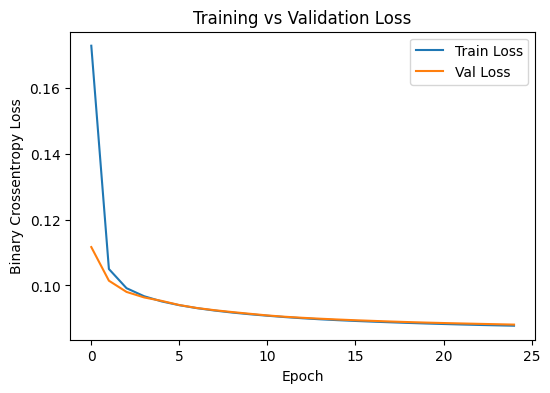

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

#### Observation
- Both the training and validation loss decrease steadily over the epochs, indicating effective learning.
- The two curves remain very close, showing good generalization with no significant overfitting.
- The loss stabilizes toward the final epochs, suggesting the model has converged.

In [19]:
# Generate denoised images from the noisy test images
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


## 10. Visualize the Denoising Results

This visualization compares the original, noisy, and denoised images produced by the Convolutional Denoising Autoencoder.

- To visually evaluate the denoising performance of the model.
- To compare the input noisy images with the reconstructed images.
- To verify that the model preserves important digit features while removing noise.

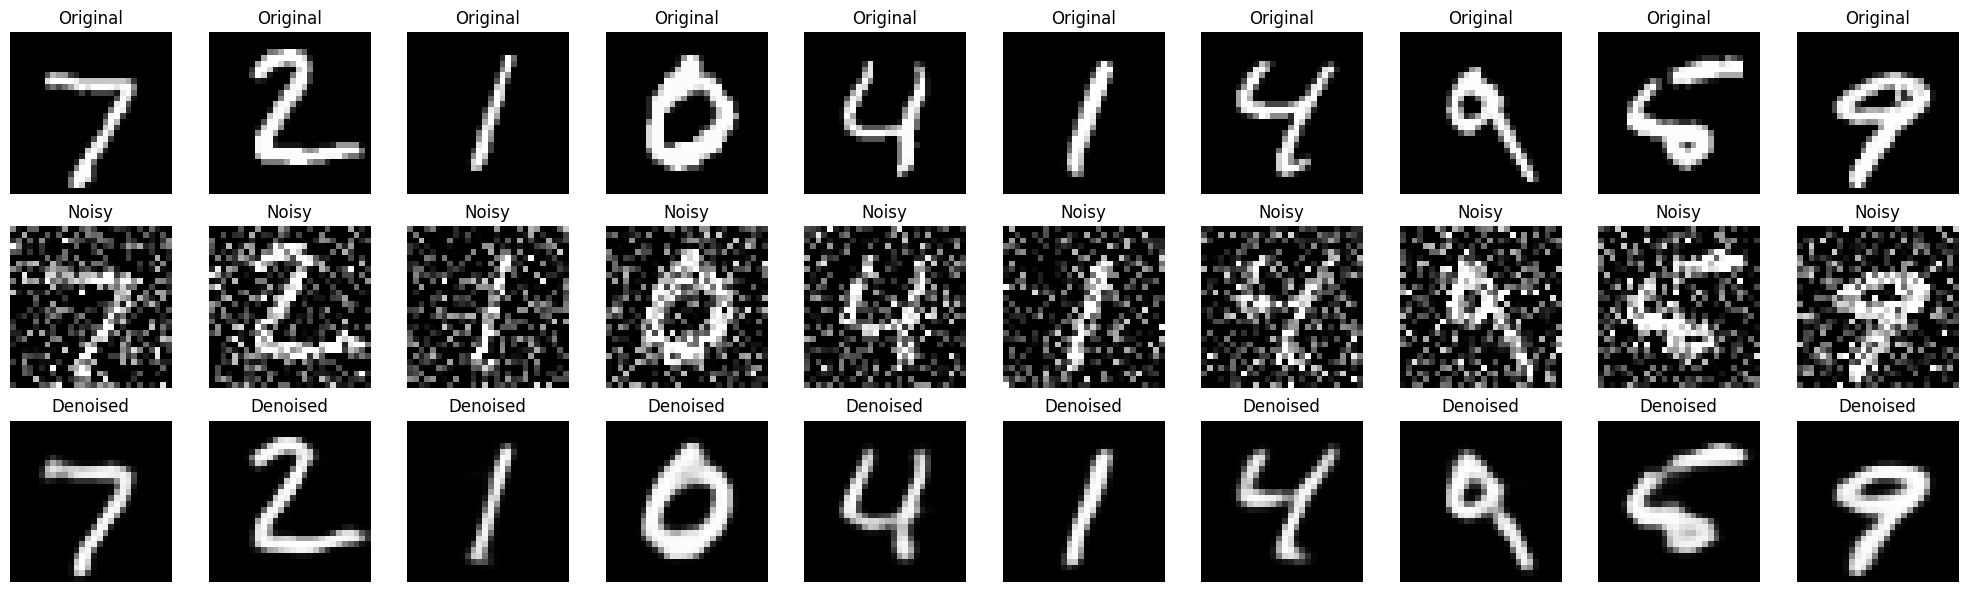

In [20]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 11. Evaluate Model Performance

This step evaluates the denoising performance of the models using quantitative metrics and compares their results.

- To measure the reconstruction quality using MSE, PSNR, and SSIM.
- To compare the performance of the Noisy Input, Dense Autoencoder, and Convolutional Autoencoder.
- To identify which model produces the best denoising results.

**Evaluation Metrics**
- MSE (Mean Squared Error): Measures the average difference between the original and reconstructed images. Lower values indicate better performance.
- PSNR (Peak Signal-to-Noise Ratio): Measures the quality of the reconstructed image compared to the original. Higher values indicate better image quality.
- SSIM (Structural Similarity Index): Measures the similarity in structure between the original and reconstructed images. Values closer to 1 indicate higher similarity.

In [21]:
mse_noisy = mean_squared_error(
    x_test.reshape(len(x_test), -1),
    x_test_noisy.reshape(len(x_test_noisy), -1)
)

mse_denoised = mean_squared_error(
    x_test.reshape(len(x_test), -1),
    denoised_images.reshape(len(denoised_images), -1)
)

def compute_psnr_ssim(originals, reconstructions):
    psnr_scores, ssim_scores = [], []
    for orig, recon in zip(originals, reconstructions):
        o = orig.squeeze()
        r = recon.squeeze()
        psnr_scores.append(psnr_metric(o, r, data_range=1.0))
        ssim_scores.append(ssim_metric(o, r, data_range=1.0))
    return np.mean(psnr_scores), np.mean(ssim_scores)

psnr_noisy, ssim_noisy = compute_psnr_ssim(x_test, x_test_noisy)
dense_psnr, dense_ssim = compute_psnr_ssim(x_test, dense_denoised_images)
psnr_denoised, ssim_denoised = compute_psnr_ssim(x_test, denoised_images)

import pandas as pd
results_table = pd.DataFrame({
    "Model / Stage": ["Noisy input", "Dense autoencoder", "Conv autoencoder"],
    "MSE": [mse_noisy, dense_mse, mse_denoised],
    "PSNR (dB)": [psnr_noisy, dense_psnr, psnr_denoised],
    "SSIM": [ssim_noisy, dense_ssim, ssim_denoised],
})

results_table

,Model / Stage,MSE,PSNR (dB),SSIM
0,Noisy input,0.079566,11.004464,0.446303
1,Dense autoencoder,0.011808,19.698399,0.858403
2,Conv autoencoder,0.008240,21.170461,0.899425


#### Observation
- The Convolutional Autoencoder achieves the **lowest MSE (0.008240), highest PSNR (21.17 dB), and highest SSIM (0.899425)**, indicating the best denoising performance.
- The Dense Autoencoder also improves image quality (MSE = 0.011808, PSNR = 19.70 dB, SSIM = 0.858403) but performs slightly worse than the Convolutional Autoencoder.
- Both autoencoder models significantly outperform the noisy input (MSE = 0.079566, PSNR = 11.00 dB, SSIM = 0.446303), demonstrating effective noise removal.

## 11.1 Visualize Convolutional Autoencoder Latent Representation

This step extracts and visualizes the **7 × 7 × 16 latent feature map** produced by the encoder for a sample test image.

- To verify the latent representation has the expected shape **(7, 7, 16)**.
- To visualize the **16 feature-map channels** learned by the encoder.
- To understand how the encoder compresses the input image into meaningful spatial features.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Conv Autoencoder latent representation shape: (1, 7, 7, 16)


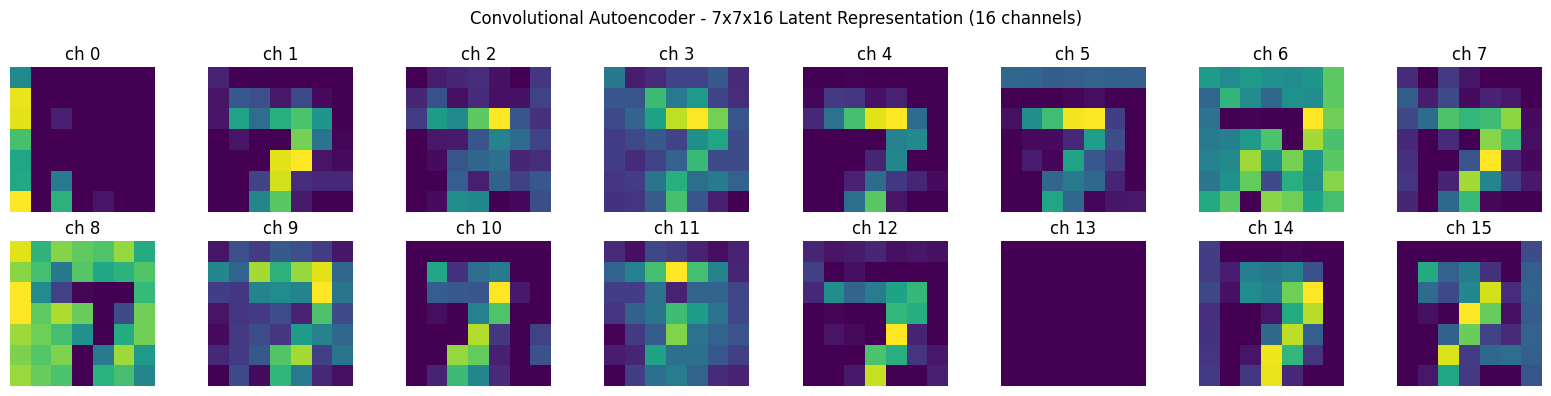

In [22]:
encoded_layer_index = 4 
conv_encoder = models.Model(inputs=autoencoder.input,
                             outputs=autoencoder.layers[encoded_layer_index].output)

sample_img = x_test_noisy[0:1]
conv_latent = conv_encoder.predict(sample_img)

print("Conv Autoencoder latent representation shape:", conv_latent.shape)  # (1, 7, 7, 16)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(conv_latent[0, :, :, i], cmap='viridis')
    ax.set_title(f"ch {i}")
    ax.axis('off')
plt.suptitle("Convolutional Autoencoder - 7x7x16 Latent Representation (16 channels)")
plt.tight_layout()
plt.show()

### Observation
- The encoder successfully compresses the input image into a latent feature map of shape (7, 7, 16).
- Each of the 16 channels captures different spatial features of the digit, such as edges, strokes, and shapes.
- Together, these feature maps provide a compact representation that the decoder uses to reconstruct the denoised image.

## 12. Noise Level Performance Analysis

This experiment tests the trained Convolutional Autoencoder on images with different noise levels to check its denoising performance.

- To evaluate the model at different noise levels.
- To observe how noise affects reconstruction quality.
- To measure the model's robustness using PSNR and SSIM.

In [23]:
noise_factors_sweep = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

sweep_results = []
for nf in noise_factors_sweep:
    x_test_noisy_nf = add_noise(x_test, noise_factor=nf)
    denoised_nf = autoencoder.predict(x_test_noisy_nf, verbose=0)

    psnr_in, ssim_in = compute_psnr_ssim(x_test, x_test_noisy_nf)
    psnr_out, ssim_out = compute_psnr_ssim(x_test, denoised_nf)

    sweep_results.append({
        "noise_factor": nf,
        "psnr_noisy": psnr_in, "ssim_noisy": ssim_in,
        "psnr_denoised": psnr_out, "ssim_denoised": ssim_out,
    })
    print(f"noise_factor={nf:.1f} -> PSNR noisy={psnr_in:.2f}dB / denoised={psnr_out:.2f}dB "
          f"| SSIM noisy={ssim_in:.3f} / denoised={ssim_out:.3f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df

noise_factor=0.1 -> PSNR noisy=22.67dB / denoised=24.08dB | SSIM noisy=0.697 / denoised=0.948
noise_factor=0.2 -> PSNR noisy=16.75dB / denoised=23.47dB | SSIM noisy=0.613 / denoised=0.941
noise_factor=0.3 -> PSNR noisy=13.32dB / denoised=22.50dB | SSIM noisy=0.528 / denoised=0.927
noise_factor=0.4 -> PSNR noisy=11.00dB / denoised=21.15dB | SSIM noisy=0.446 / denoised=0.899
noise_factor=0.5 -> PSNR noisy=9.38dB / denoised=19.43dB | SSIM noisy=0.375 / denoised=0.829
noise_factor=0.6 -> PSNR noisy=8.24dB / denoised=17.45dB | SSIM noisy=0.318 / denoised=0.719
noise_factor=0.7 -> PSNR noisy=7.42dB / denoised=15.61dB | SSIM noisy=0.273 / denoised=0.609


,noise_factor,psnr_noisy,ssim_noisy,psnr_denoised,ssim_denoised
0,0.1,22.665435,0.696827,24.078666,0.948065
1,0.2,16.752947,0.612599,23.469252,0.940725
2,0.3,13.322926,0.527750,22.497761,0.927163
3,0.4,10.997646,0.445975,21.151049,0.898791
4,0.5,9.379253,0.375120,19.427200,0.828947
5,0.6,8.243516,0.318047,17.449211,0.719077
6,0.7,7.423138,0.272661,15.605932,0.609260


#### Observation
- As the noise factor increases from 0.1 to 0.7, the denoised PSNR decreases from 24.08 dB to 15.61 dB, while SSIM decreases from 0.948 to 0.609, indicating a gradual reduction in reconstruction quality.
- The Convolutional Autoencoder consistently outperforms the noisy input, improving PSNR (e.g., 11.00 -> 21.15 dB at noise factor = 0.4) and SSIM (e.g., 0.446 -> 0.899).
- The model achieves the highest reconstruction quality at noise factor = 0.1 and continues to provide effective denoising even at higher noise levels, demonstrating good robustness.

## 12.1  Visualize Performance at Different Noise Levels

This plot shows how the model's performance changes as the noise level increases.

- To compare the PSNR and SSIM of noisy and denoised images.
- To observe the effect of increasing noise on image quality.
- To evaluate the model's robustness across different noise levels.

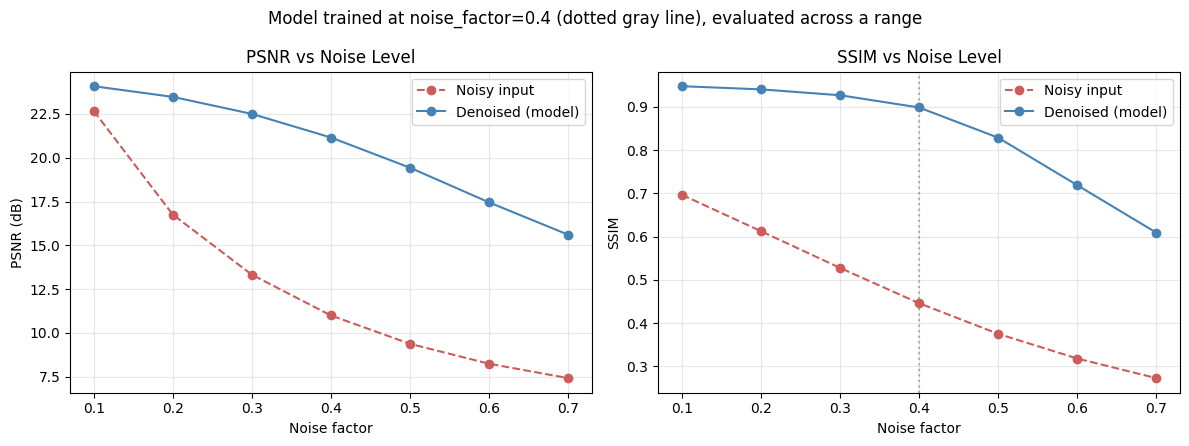

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(sweep_df["noise_factor"], sweep_df["psnr_noisy"], 'o--', label='Noisy input', color='indianred')
axes[0].plot(sweep_df["noise_factor"], sweep_df["psnr_denoised"], 'o-', label='Denoised (model)', color='steelblue')
axes[0].set_xlabel('Noise factor')
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR vs Noise Level')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sweep_df["noise_factor"], sweep_df["ssim_noisy"], 'o--', label='Noisy input', color='indianred')
axes[1].plot(sweep_df["noise_factor"], sweep_df["ssim_denoised"], 'o-', label='Denoised (model)', color='steelblue')
axes[1].set_xlabel('Noise factor')
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM vs Noise Level')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.axvline(NOISE_FACTOR, color='gray', linestyle=':', alpha=0.6)
plt.suptitle(f'Model trained at noise_factor={NOISE_FACTOR} (dotted gray line), evaluated across a range')
plt.tight_layout()
plt.show()

#### Observation
- As the noise factor increases, both PSNR and SSIM gradually decrease, indicating lower reconstruction quality.
- The Convolutional Autoencoder consistently achieves higher PSNR and SSIM than the noisy input across all noise levels.
- The model performs best at noise factor = 0.1 and maintains good denoising performance even at the training noise level (0.4) and higher noise levels.

## 12.2  Visualize Denoised Images at Different Noise Levels
This visualization shows how the trained model reconstructs the same test images as the noise level increases.

- To visually compare denoised images at different noise levels.
- To observe how increasing noise affects reconstruction quality.
- To evaluate the model's robustness under varying noise conditions.

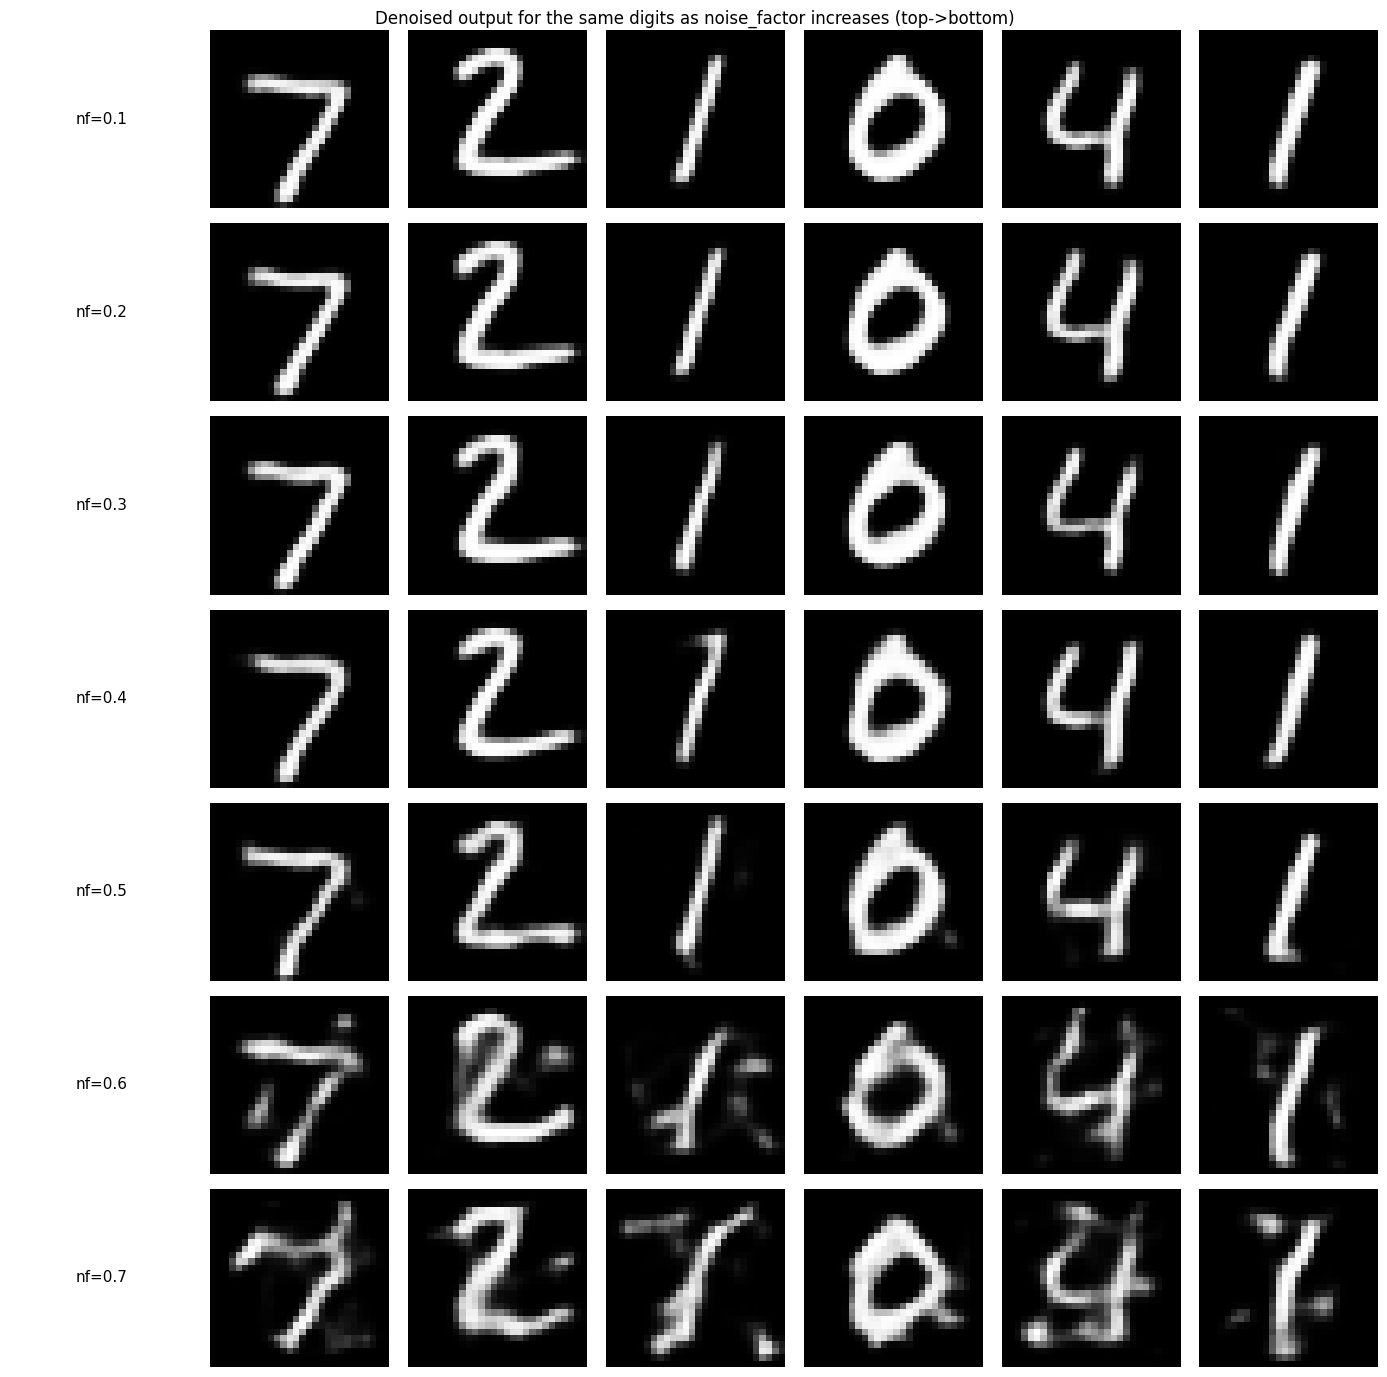

In [25]:
sample_idx = list(range(6))
fig, axes = plt.subplots(len(noise_factors_sweep), len(sample_idx) + 1, figsize=(2*(len(sample_idx)+1), 2*len(noise_factors_sweep)))

for row, nf in enumerate(noise_factors_sweep):
    x_noisy_nf = add_noise(x_test[sample_idx], noise_factor=nf)
    denoised_nf = autoencoder.predict(x_noisy_nf, verbose=0)
    axes[row, 0].text(0.5, 0.5, f"nf={nf}", ha='center', va='center', fontsize=11)
    axes[row, 0].axis('off')
    for col in range(len(sample_idx)):
        axes[row, col+1].imshow(denoised_nf[col].squeeze(), cmap='gray')
        axes[row, col+1].axis('off')

plt.suptitle("Denoised output for the same digits as noise_factor increases (top->bottom)")
plt.tight_layout()
plt.show()

#### Observation
- At low noise levels (nf = 0.1–0.4), the model reconstructs the digits clearly, preserving their shapes with minimal distortion.
- At nf = 0.5, slight blurring and a few noise artifacts appear, but the digits remain easily recognizable.
At higher noise levels (nf = 0.6–0.7), more artifacts and blurred edges are visible, reducing reconstruction quality.
- Despite the increase in noise, the model successfully preserves the overall digit structure across all noise levels, demonstrating good robustness.

## 13. Save the Trained Models

This step saves the trained Convolutional Autoencoder and Dense Autoencoder 

In [26]:
os.makedirs("saved_models", exist_ok=True)

autoencoder.save("saved_models/conv_denoising_autoencoder.keras")   # main model
dense_autoencoder.save("saved_models/dense_denoising_autoencoder.keras")  # dense baseline

print("Saved models:")
for f in os.listdir("saved_models"):
    print(" -", f)

Saved models:
 - dense_denoising_autoencoder.keras
 - conv_denoising_autoencoder.keras


## Conclusion

- The **Convolutional Autoencoder achieved the best performance with the lowest MSE (0.008240), highest PSNR (21.17 dB), and highest SSIM (0.899425)**, outperforming the Dense Autoencoder (MSE = 0.011808, PSNR = 19.70 dB, SSIM = 0.858403).
- Compared to the noisy input (MSE = 0.079566, PSNR = 11.00 dB, SSIM = 0.446303), both models greatly improved reconstruction quality.
- Denoising quality holds up well near the trained noise level (0.4) but degrades at higher, unseen noise factors - showing the model's performance is tied to the noise range it was trained on.
- **Key challenge:** balancing noise removal with preservation of fine digit strokes; too much smoothing risks losing structure, too little leaves residual noise.
- **Takeaway:** a lightweight convolutional encoder-decoder is sufficient for effective denoising on MNIST, and could be extended with a wider range of noise types/levels during training for more robust real-world use.